In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier


In [2]:
data = pd.read_csv('PlayTennis.csv')

In [5]:
data.head(2)

,Outlook,Temperature,Humidity,Wind,Play Tennis
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No


In [8]:
from sklearn.preprocessing import OrdinalEncoder,LabelEncoder

In [ ]:
outlook_encoder = OrdinalEncoder()
data['Outlook']  =outlook_encoder.fit_transform(data[['Outlook']])


,Outlook,Temperature,Humidity,Wind,Play Tennis
0,2.0,Hot,High,Weak,No
1,2.0,Hot,High,Strong,No
2,0.0,Hot,High,Weak,Yes
3,1.0,Mild,High,Weak,Yes
4,1.0,Cool,Normal,Weak,Yes
5,1.0,Cool,Normal,Strong,No
6,0.0,Cool,Normal,Strong,Yes
7,2.0,Mild,High,Weak,No
8,2.0,Cool,Normal,Weak,Yes
9,1.0,Mild,Normal,Weak,Yes


In [9]:
le = LabelEncoder()
for col in data.columns:
    data[col] =  le.fit_transform(data[col])

In [24]:
play_encoder = OrdinalEncoder()
data['play'] = play_encoder.fit_transform(data[['Play Tennis']])

In [14]:
x = data.drop(['Play Tennis'], axis = 1)
y = data['Play Tennis']

In [15]:
clf_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
clf_gini.fit(x,y)
y_pred_gini  = clf_gini.predict(x)


In [16]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [21]:
print("accuracy_score", accuracy_score(y, y_pred_gini))
print("", classification_report(y, y_pred_gini))
print("", confusion_matrix(y, y_pred_gini))

accuracy_score 1.0
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         9

    accuracy                           1.00        14
   macro avg       1.00      1.00      1.00        14
weighted avg       1.00      1.00      1.00        14

 [[5 0]
 [0 9]]


[Text(0.4444444444444444, 0.9, 'Outlook <= 0.5\ngini = 0.459\nsamples = 14\nvalue = [5, 9]\nclass = y[1]'),
 Text(0.3333333333333333, 0.7, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]\nclass = y[1]'),
 Text(0.38888888888888884, 0.8, 'True  '),
 Text(0.5555555555555556, 0.7, 'Humidity <= 0.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]\nclass = y[0]'),
 Text(0.5, 0.8, '  False'),
 Text(0.3333333333333333, 0.5, 'Outlook <= 1.5\ngini = 0.32\nsamples = 5\nvalue = [4, 1]\nclass = y[0]'),
 Text(0.2222222222222222, 0.3, 'Wind <= 0.5\ngini = 0.5\nsamples = 2\nvalue = [1, 1]\nclass = y[0]'),
 Text(0.1111111111111111, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]\nclass = y[0]'),
 Text(0.3333333333333333, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]\nclass = y[1]'),
 Text(0.4444444444444444, 0.3, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]\nclass = y[0]'),
 Text(0.7777777777777778, 0.5, 'Wind <= 0.5\ngini = 0.32\nsamples = 5\nvalue = [1, 4]\nclass = y[1]'),
 Text(0.6666666666666666, 0.3, 'Temperature <= 

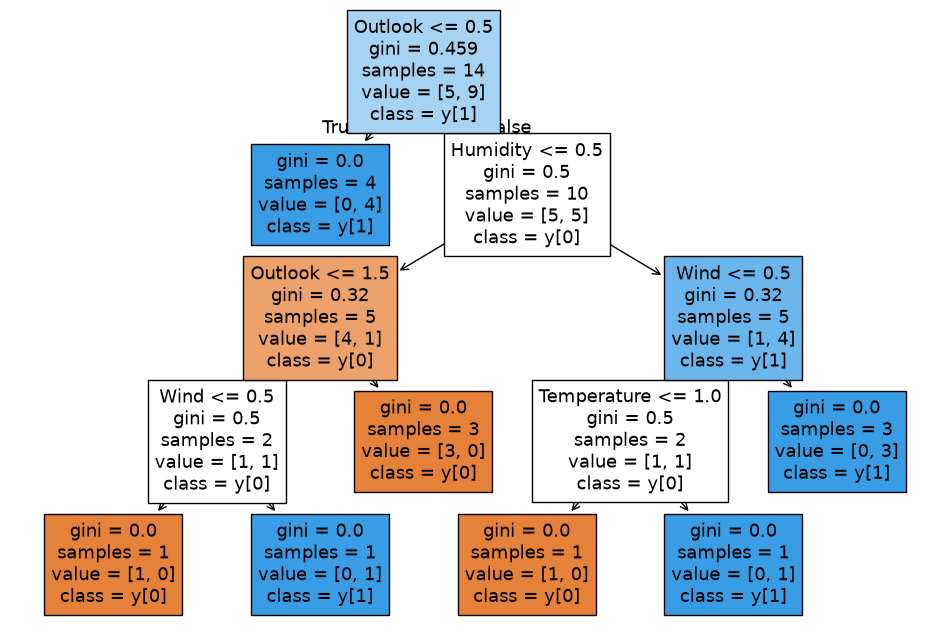

In [34]:
from sklearn import tree
plt.figure(figsize=(12,8))
tree.plot_tree(clf_gini, filled=True, feature_names=x.columns, class_names=True)